In [2]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from tqdm.auto import tqdm
from wordcloud import WordCloud
from PIL import Image

basepath = "../dataset/images/tower"
DEVICE = (
    "mps"
    if torch.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

/Users/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
df = pl.read_csv("../dataset/csv/towers.csv")
df = df.filter(pl.col("country_code") == "JP")
df
# df.head()

category,id,owner,title,datetaken,tags,latitude,longitude,place_id,img_id,country_code,country,region,subregion,city
str,i64,str,str,i64,str,f64,f64,str,str,str,str,str,str,str
"""tower""",20836418442,"""97297390@N05""","""西崎燈塔""",1435676400,"""lighthouse bright serenity 與那國…",24.450259,122.934411,"""k6u6UrRQU7vPSiRo""","""tower-24.450259-122.934411-143…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Yonakuni"""
"""tower""",26855834432,"""45206453@N07""","""Hatoma: Light house""",1460062294,"""japan islands yaeyama nature b…",24.47091,123.82037,"""Wu6m1u9QU7rAw3FW""","""tower-24.470910-123.820370-146…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ishigaki"""
"""tower""",29827910152,"""91975591@N07""","""Ryukyu Kannonzaki Lighthouse (…",1474786608,"""ryukyukannonsakilighthouse ryu…",24.365764,124.11154,"""Rt3GYDpQU7tQT2Ka""","""tower-24.365764-124.111540-147…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ishigaki"""
"""tower""",29315017064,"""91975591@N07""","""Ryukyu Kannonzaki Lighthouse (…",1474786610,"""ryukyukannonsakilighthouse ryu…",24.365764,124.11154,"""Rt3GYDpQU7tQT2Ka""","""tower-24.365764-124.111540-147…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ishigaki"""
"""tower""",29827884232,"""91975591@N07""","""Ryukyu Kannonzaki Lighthouse (…",1474786624,"""ryukyukannonsakilighthouse ryu…",24.365764,124.11154,"""Rt3GYDpQU7tQT2Ka""","""tower-24.365764-124.111540-147…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ishigaki"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""tower""",14879541662,"""40295335@N00""","""Invisible lighthouse, Cape Nos…",1406006819,"""lighthouse japan fog hokkaido …",43.385827,145.812666,"""UiD_akBTWr8oI.Pplw""","""tower-43.385827-145.812666-140…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nemuro"""
"""tower""",7834172398,"""28695036@N06""","""Nosappu misaki lighthouse""",1343276247,"""sea sky lighthouse green bird …",43.385063,145.816316,"""UiD_akBTWr8oI.Pplw""","""tower-43.385063-145.816316-134…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nemuro"""
"""tower""",7834171082,"""28695036@N06""","""Nosappu misaki lighthouse""",1343276308,"""sea sky lighthouse green grass…",43.385119,145.816408,"""UiD_akBTWr8oI.Pplw""","""tower-43.385119-145.816408-134…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nemuro"""


In [12]:
coords = df[["latitude", "longitude"]].to_numpy()
coords = np.radians(coords)

#### Cluster with DBSCAN

In [13]:
R = 6371.0
eps_km = 0.1
eps_rad = eps_km / R

dbscan = DBSCAN(eps=eps_rad, metric="haversine", min_samples=50)
labels = dbscan.fit_predict(coords)
df = df.with_columns(pl.Series("cluster_id", labels))
print(f"Total cluster: {df['cluster_id'].n_unique()}")

Total cluster: 39


In [14]:
df = df.filter(pl.col("cluster_id") > -1).with_row_index("row_idx")
df_filtered = df.to_pandas()

fig = px.scatter_map(
    df_filtered,
    lat="latitude",
    lon="longitude",
    zoom=12,
    center={"lat": 35.6895, "lon": 139.7517},
    color="cluster_id",
)

fig.update_layout(height=700, width=1400, margin=dict(l=10, r=10, t=10, b=10))

fig.show()

In [16]:
df.write_csv("../dataset/csv/towers_w_cluster.csv")

#### Identify centroid of each cluster

In [79]:
def spherical_centroid(lats, lons):
    lat_rad = np.radians(lats)
    lon_rad = np.radians(lons)

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    x_mean = x.mean()
    y_mean = y.mean()
    z_mean = z.mean()

    lon_centroid = np.arctan2(y_mean, x_mean)
    hyp = np.sqrt(x_mean**2 + y_mean**2)
    lat_centroid = np.arctan2(z_mean, hyp)

    return np.degrees(lat_centroid), np.degrees(lon_centroid)


def mean_centroid(lats, lons):
    return np.mean(lats), np.mean(lons)


def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [80]:
# cluster_to_centroid = []
df_centroid = []
for cluster_id, item in df.group_by("cluster_id"):
    latlons = item[["latitude", "longitude"]]
    lats = latlons[:, 0]
    lons = latlons[:, 1]

    clat, clon = spherical_centroid(lats, lons)
    df_centroid.append(
        {
            "cluster_id": cluster_id[0],
            "latitude": clat.item(),
            "longitude": clon.item(),
            "n_points": len(item),
        }
    )

In [81]:
df_centroid = pl.DataFrame(df_centroid).sort("cluster_id")
df_centroid = df_centroid.join(
    df.group_by("cluster_id").agg(pl.col("row_idx").alias("member")), on="cluster_id"
).sort("cluster_id")

df_centroid

cluster_id,latitude,longitude,n_points,member
i64,f64,f64,i64,list[u32]
0,35.097355,129.037016,67,"[0, 1, … 116]"
1,35.190293,129.222865,50,"[3, 4, … 52]"
2,34.705282,135.49024,260,"[117, 118, … 541]"
3,34.682587,135.186738,100,"[121, 122, … 550]"
4,34.680106,135.184808,74,"[158, 284, … 549]"
…,…,…,…,…
35,35.683743,139.768564,60,"[1638, 7802, … 8452]"
36,35.716186,139.794698,61,"[8026, 8031, … 10476]"
37,35.707873,140.868542,76,"[10529, 10530, … 10604]"


#### Measure the inter-cluster distance

##### Geometric Prefilter

In [82]:
from sklearn.neighbors import BallTree

centroid_coords = df_centroid[["latitude", "longitude"]].to_numpy()
centroid_coords = np.radians(centroid_coords)

tree = BallTree(centroid_coords, metric="haversine")

In [83]:
query_rads = 1 / R
indices, distances = tree.query_radius(
    centroid_coords, r=query_rads, return_distance=True
)

In [84]:
cluster_neighbor = []

for i, (ind, dist) in enumerate(zip(indices, distances)):
    cluster_neighbor.append(
        {"cluster_id": i, "neighbors": ind.tolist(), "distances": dist.tolist()}
    )
cluster_neighbor = pl.DataFrame(cluster_neighbor)

In [85]:
df_centroid = df_centroid.join(cluster_neighbor, on="cluster_id")
df_centroid

cluster_id,latitude,longitude,n_points,member,neighbors,distances
i64,f64,f64,i64,list[u32],list[i64],list[f64]
0,35.097355,129.037016,67,"[0, 1, … 116]",[0],[0.0]
1,35.190293,129.222865,50,"[3, 4, … 52]",[1],[0.0]
2,34.705282,135.49024,260,"[117, 118, … 541]",[2],[0.0]
3,34.682587,135.186738,100,"[121, 122, … 550]","[3, 4]","[0.0, 0.000051]"
4,34.680106,135.184808,74,"[158, 284, … 549]","[3, 4]","[0.000051, 0.0]"
…,…,…,…,…,…,…
35,35.683743,139.768564,60,"[1638, 7802, … 8452]","[34, 35]","[0.000061, 0.0]"
36,35.716186,139.794698,61,"[8026, 8031, … 10476]","[14, 33, 36]","[0.000086, 0.000156, 0.0]"
37,35.707873,140.868542,76,"[10529, 10530, … 10604]",[37],[0.0]


In [86]:
df_centroid[14]["neighbors"].to_list()

[[14, 30, 33, 36]]

In [87]:
_fig = px.scatter_map(
    df_centroid.to_pandas(),
    lat="latitude",
    lon="longitude",
    zoom=12,
    center={"lat": 35.6895, "lon": 139.7517},
    color="cluster_id",
)

_fig.update_layout(height=700, width=1400, margin=dict(l=10, r=10, t=10, b=10))

_fig.show()

##### Inter-Cluster Textual Similarity

In [88]:
df = df.with_columns(pl.concat_str(["title", "tags"], separator=" ").alias("text"))
cluster14 = df.filter(pl.col("cluster_id") == 14)["text"].to_list()
cluster30 = df.filter(pl.col("cluster_id") == 30)["text"].to_list()
cluster33 = df.filter(pl.col("cluster_id") == 33)["text"].to_list()
cluster36 = df.filter(pl.col("cluster_id") == 36)["text"].to_list()
cluster15 = df.filter(pl.col("cluster_id") == 15)["text"].to_list()

cluster17 = df.filter(pl.col("cluster_id") == 17)["text"].to_list()
cluster20 = df.filter(pl.col("cluster_id") == 20)["text"].to_list()
cluster19 = df.filter(pl.col("cluster_id") == 19)["text"].to_list()
cluster24 = df.filter(pl.col("cluster_id") == 24)["text"].to_list()
cluster13 = df.filter(pl.col("cluster_id") == 13)["text"].to_list()

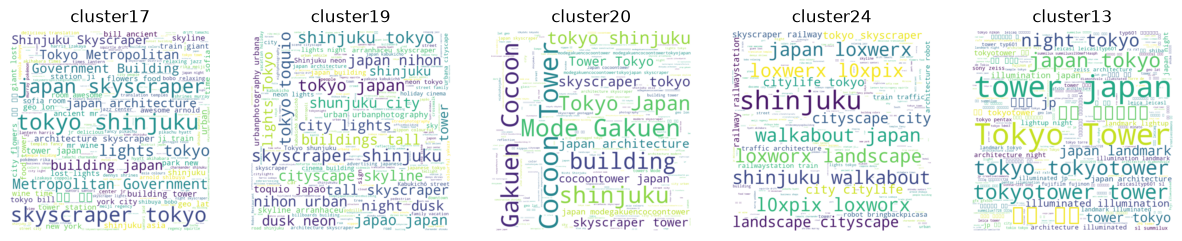

In [89]:
# wordcloud analysis

fig, ax = plt.subplots(1, 5, figsize=(15, 10))
ax[0].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster17)
    ),
    interpolation="bilinear",
)
ax[0].set_title("cluster17")
ax[1].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster19)
    ),
    interpolation="bilinear",
)
ax[1].set_title("cluster19")
ax[2].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster20)
    ),
    interpolation="bilinear",
)
ax[2].set_title("cluster20")
ax[3].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster24)
    ),
    interpolation="bilinear",
)
ax[3].set_title("cluster24")
ax[4].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster13)
    ),
    interpolation="bilinear",
)
ax[4].set_title("cluster13")

ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")
ax[3].axis("off")
ax[4].axis("off")
plt.show()

In [90]:
from gliner import GLiNER

ner = GLiNER.from_pretrained("urchade/gliner_multi-v2.1", load_tokenizer=True).to(
    DEVICE
)

/Users/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 58092.85it/s]


In [94]:
from gliner import GLiNER

ner = GLiNER.from_pretrained("urchade/gliner_multi-v2.1", load_tokenizer=True).to(
    DEVICE
)

all_ner = []
labels = ["tower"]

for txt in tqdm(df["text"].to_list(), desc="NER"):
    entities = ner.predict_entities(txt, labels, threshold=0.5)
    all_ner.append([e["text"] for e in entities])

df = df.with_columns(pl.Series("entities", all_ner))

NER: 100%|██████████| 10777/10777 [04:36<00:00, 38.98it/s]


In [111]:
cluster14_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 14)["entities"].to_list()
    for i in ent
]
cluster30_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 30)["entities"].to_list()
    for i in ent
]
cluster33_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 33)["entities"].to_list()
    for i in ent
]
cluster36_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 36)["entities"].to_list()
    for i in ent
]
cluster15_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 15)["entities"].to_list()
    for i in ent
]

#
cluster17_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 17)["entities"].to_list()
    for i in ent
]
cluster20_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 20)["entities"].to_list()
    for i in ent
]
cluster19_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 19)["entities"].to_list()
    for i in ent
]
cluster24_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 24)["entities"].to_list()
    for i in ent
]
cluster13_ner = [
    i
    for ent in df.filter(pl.col("cluster_id") == 13)["entities"].to_list()
    for i in ent
]

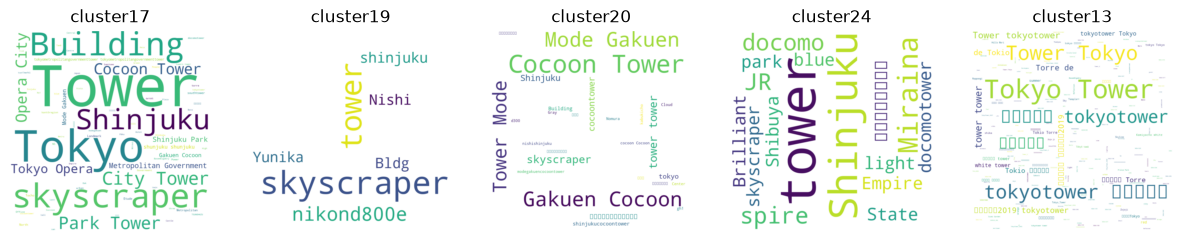

In [112]:
# wordcloud analysis

fig, ax = plt.subplots(1, 5, figsize=(15, 10))
ax[0].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster17_ner)
    ),
    interpolation="bilinear",
)
ax[1].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster19_ner)
    ),
    interpolation="bilinear",
)
ax[2].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster20_ner)
    ),
    interpolation="bilinear",
)
ax[3].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster24_ner)
    ),
    interpolation="bilinear",
)
ax[4].imshow(
    WordCloud(width=800, height=800, background_color="white").generate(
        " ".join(cluster13_ner)
    ),
    interpolation="bilinear",
)

ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")
ax[3].axis("off")
ax[4].axis("off")
ax[0].set_title("cluster17")
ax[1].set_title("cluster19")
ax[2].set_title("cluster20")
ax[3].set_title("cluster24")
ax[4].set_title("cluster13")

plt.show()

TF-IDF

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
vectorizer.fit([i for ent in df["entities"].to_list() for i in ent])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

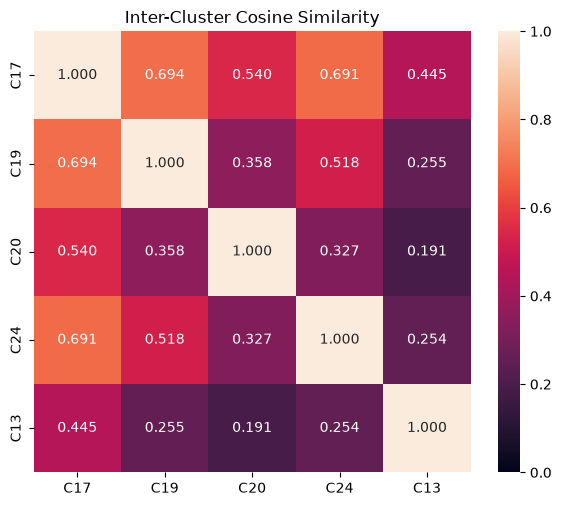

In [114]:
cluster14_feat = np.array(vectorizer.transform(cluster14_ner).mean(axis=0))
cluster30_feat = np.array(vectorizer.transform(cluster30_ner).mean(axis=0))
cluster33_feat = np.array(vectorizer.transform(cluster33_ner).mean(axis=0))
cluster36_feat = np.array(vectorizer.transform(cluster36_ner).mean(axis=0))
cluster15_feat = np.array(vectorizer.transform(cluster15_ner).mean(axis=0))
labels = ["C14", "C30", "C33", "C36", "C15"]

cluster17_feat = np.array(vectorizer.transform(cluster17_ner).mean(axis=0))
cluster20_feat = np.array(vectorizer.transform(cluster20_ner).mean(axis=0))
cluster19_feat = np.array(vectorizer.transform(cluster19_ner).mean(axis=0))
cluster24_feat = np.array(vectorizer.transform(cluster24_ner).mean(axis=0))
cluster13_feat = np.array(vectorizer.transform(cluster13_ner).mean(axis=0))
labels = ["C17", "C19", "C20", "C24", "C13"]

adj_cosine = cosine_similarity(
    np.vstack(
        (
            [
                cluster17_feat,
                cluster19_feat,
                cluster20_feat,
                cluster24_feat,
                cluster13_feat,
            ]
        )
    )
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    adj_cosine,
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1,
    ax=ax,
)
plt.tight_layout()
plt.title("Inter-Cluster Cosine Similarity")
plt.show()

Jaccard Similarity

In [ ]:
def jaccard_sim(a, b):
    s1, s2 = set(a), set(b)
    inter = len(s1 & s2)
    union = len(s1 | s2)
    return inter / union if union > 0 else 0.0


def weighted_jaccard_sim(a, b):
    s1, s2 = Counter(a), Counter(b)
    keys = set(s1) | set(s2)
    minsum = sum(min(s1[i], s2[i]) for i in keys)
    maxsum = sum(max(s1[i], s2[i]) for i in keys)
    return minsum / maxsum

In [ ]:
clusters_tags = {
    "C17": cluster17_ner,
    "C19": cluster19_ner,
    "C20": cluster20_ner,
    "C24": cluster24_ner,
    "C13": cluster13_ner,
}

labels = list(clusters_tags.keys())
adj_jaccard = np.zeros((len(labels), len(labels)))
for i, la in enumerate(labels):
    for j, lb in enumerate(labels):
        adj_jaccard[i, j] = jaccard_sim(clusters_tags[la], clusters_tags[lb])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    adj_jaccard,
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=1,
    ax=ax,
)
plt.tight_layout()
plt.title("Inter-Cluster Jaccard Similarity")
plt.show()

Centroid embedding similarity

In [ ]:
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-small")
e5 = AutoModel.from_pretrained("intfloat/multilingual-e5-small")

In [ ]:
e5 = e5.to(DEVICE)
e5 = e5.eval()

In [ ]:
cluster3_tags = [f"query: {k}" for k, c in Counter(cluster3_ner).most_common(5)]
cluster4_tags = [f"query: {k}" for k, c in Counter(cluster4_ner).most_common(5)]
cluster5_tags = [f"query: {k}" for k, c in Counter(cluster5_ner).most_common(5)]
cluster8_tags = [f"query: {k}" for k, c in Counter(cluster8_ner).most_common(5)]

In [ ]:
def average_pool(last_hidden_states, attention_mask):
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

In [ ]:
with torch.no_grad():
    cluster3_inp = tokenizer(
        cluster3_tags, max_length=32, padding="max_length", return_tensors="pt"
    )
    cluster3_emb = e5(**{k: v.to(DEVICE) for k, v in cluster3_inp.items()})
    cluster3_emb = F.normalize(
        average_pool(
            cluster3_emb.last_hidden_state.cpu(), cluster3_inp["attention_mask"]
        ),
        dim=-1,
    )

    cluster4_inp = tokenizer(
        cluster4_tags, max_length=32, padding="max_length", return_tensors="pt"
    )
    cluster4_emb = e5(**{k: v.to(DEVICE) for k, v in cluster4_inp.items()})
    cluster4_emb = F.normalize(
        average_pool(
            cluster4_emb.last_hidden_state.cpu(), cluster4_inp["attention_mask"]
        ),
        dim=-1,
    )

    cluster5_inp = tokenizer(
        cluster5_tags, max_length=32, padding="max_length", return_tensors="pt"
    )
    cluster5_emb = e5(**{k: v.to(DEVICE) for k, v in cluster5_inp.items()})
    cluster5_emb = F.normalize(
        average_pool(
            cluster5_emb.last_hidden_state.cpu(), cluster5_inp["attention_mask"]
        ),
        dim=-1,
    )

    cluster8_inp = tokenizer(
        cluster8_tags, max_length=32, padding="max_length", return_tensors="pt"
    )
    cluster8_emb = e5(**{k: v.to(DEVICE) for k, v in cluster8_inp.items()})
    cluster8_emb = F.normalize(
        average_pool(
            cluster8_emb.last_hidden_state.cpu(), cluster8_inp["attention_mask"]
        ),
        dim=-1,
    )

In [ ]:
F.normalize(torch.mean(cluster3_emb, dim=0), dim=-1) @ F.normalize(
    torch.mean(cluster8_emb, dim=0), dim=-1
).T

##### Visual prefilter

In [ ]:
import torch
from PIL import Image
from transformers import AutoModel, AutoProcessor

basepath = "../dataset/images/tower"
device = "mps" if torch.mps.is_available() else "cpu"
processor = AutoProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)

In [ ]:
embeddings = []

with torch.no_grad():
    for i, row in enumerate(tqdm(df.to_dicts())):
        img = processor(
            Image.open(os.path.join(basepath, row["img_id"])), return_tensors="pt"
        )
        out = (
            model(**{k: v.to(device) for k, v in img.items()})
            .pooler_output.cpu()
            .squeeze()
        )
        # qclient.upsert(
        #     collection_name="tower-tokyo",
        #     points=[models.PointStruct(id=i, payload=row, vector=out.tolist())],
        # )
        embeddings.append(out)

embeddings = torch.vstack(embeddings)
embeddings

In [ ]:
from PIL import Image

embeddings = []
with torch.no_grad():
    for i, row in enumerate(tqdm(df.to_dicts())):
        img = processor(
            Image.open(os.path.join(basepath, row["img_id"])), return_tensors="pt"
        )
        out = model(**{k: v.to(device) for k, v in img.items()}).pooler_output.cpu().squeeze()
        embeddings.append(out)

embeddings = torch.vstack(embeddings)
embeddings

In [ ]:
centroid_embeddings = torch.zeros(len(df_centroid), 384)
for row in df.group_by("cluster_id").agg(pl.col("row_idx").alias("member")).to_dict():
    centroid_embeddings[row["cluster_id"]] = F.normalize(torch.mean(F.normalize(embeddings[row["member"]], dim=-1), dim=0), dim=-1)

In [ ]:
centroid_embeddings = torch.zeros((len(df_centroid), 384))
for row in df.group_by("cluster_id").agg(pl.col("row_idx").alias("member")).to_dicts():
    centroid_embeddings[row["cluster_id"]] = F.normalize(
        torch.mean(F.normalize(embeddings[row["member"]], dim=-1), dim=0), dim=-1
    )

centroid_embeddings

In [ ]:
# for item in tokyo_centroid.to_dicts():
#     emb_anchor = centroid_embeddings[item["cluster_id"]]
#     neighbor_ind = [it for it in item["neighbors"] if it != item["cluster_id"]]
#     emb_neighbor = centroid_embeddings[neighbor_ind]
#     break

item = df_centroid.to_dicts()[3]
emb_anchor = centroid_embeddings[item["cluster_id"]]
neighbor_ind = [it for it in item["neighbors"] if it != item["cluster_id"]]
emb_neighbor = centroid_embeddings[neighbor_ind]
print(neighbor_ind)
emb_anchor @ emb_neighbor.T

In [ ]:
from sklearn_extra.cluster import KMedoids


def get_medoids(cluster_embeddings, k=5):
    k = min(k, len(cluster_embeddings))
    km = KMedoids(n_clusters=k, metric="cosine", method="pam", random_state=42)
    km.fit(cluster_embeddings)
    medoid_indices = km.medoid_indices_
    return medoid_indices

In [ ]:
cluster3_medoid = get_medoids(embeddings[df_centroid.to_dicts()[3]["member"]].numpy())
cluster8_medoid = get_medoids(embeddings[df_centroid.to_dicts()[8]["member"]].numpy())

In [ ]:
cluster3_medoid_emb = F.normalize(
    embeddings[df_centroid.to_dicts()[3]["member"]][cluster3_medoid], dim=-1
)
cluster8_medoid_emb = F.normalize(
    embeddings[df_centroid.to_dicts()[8]["member"]][cluster8_medoid], dim=-1
)

In [ ]:
sim = (cluster3_medoid_emb @ cluster8_medoid_emb.T).numpy()
best_match_3_8 = sim.max(axis=1)
best_match_8_3 = sim.max(axis=0)

matches_3_8 = (best_match_3_8 > 0.75).sum()
matches_8_3 = (best_match_8_3 > 0.75).sum()
(matches_3_8 + matches_8_3) / (len(cluster3_medoid) + len(cluster8_medoid))

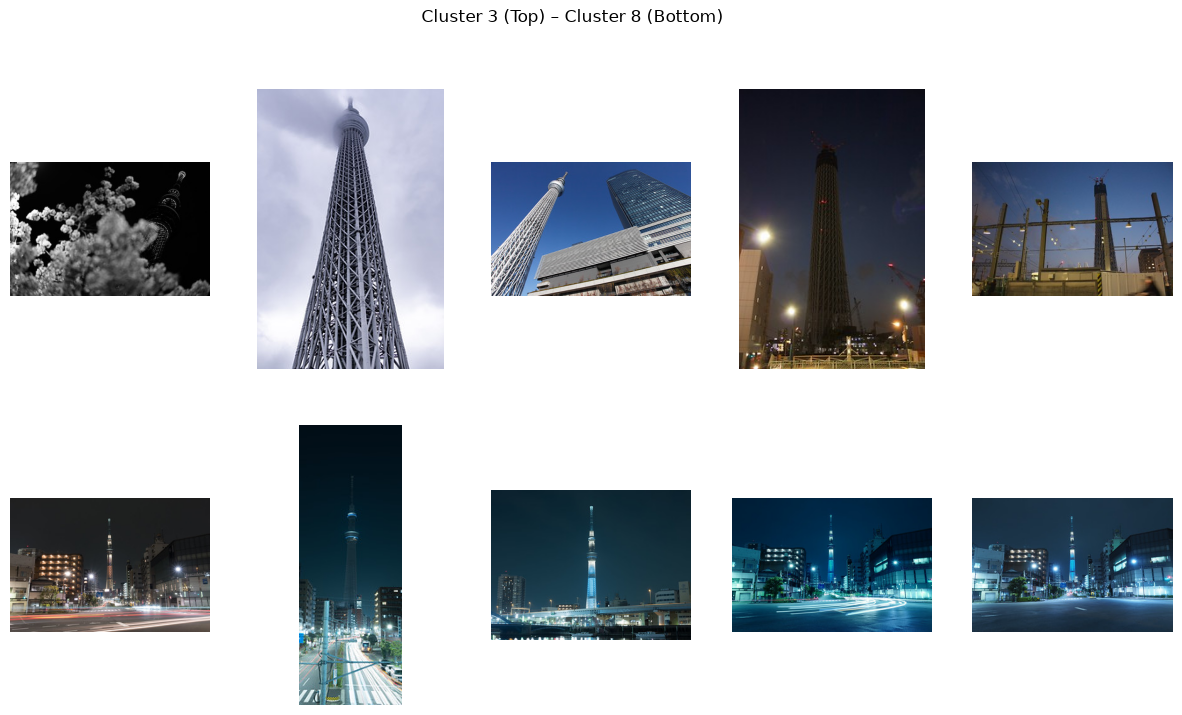

In [120]:
import matplotlib.pyplot as plt
from PIL import Image

fig, ax = plt.subplots(2, 5, figsize=(15, 8))
for ii, it in enumerate(df.filter(pl.col("cluster_id") == 15).sample(5).to_dicts()):
    ax[0][ii].imshow(Image.open(os.path.join(basepath, it["img_id"])))
    ax[0][ii].axis("off")
for ii, it in enumerate(df.filter(pl.col("cluster_id") == 33).sample(5).to_dicts()):
    ax[1][ii].imshow(Image.open(os.path.join(basepath, it["img_id"])))
    ax[1][ii].axis("off")
fig.suptitle("Cluster 3 (Top) – Cluster 8 (Bottom)")
plt.show()